In [4]:
import numpy as np

import pyvista as pv
from pyvista import examples
pv.set_jupyter_backend('pythreejs')

C:\Users\fly\AppData\Local\Temp\ipykernel_12464\679715708.py:5: PyVistaDeprecationWarning: `pythreejs` backend is deprecated and is planned for future removal.
  pv.set_jupyter_backend('pythreejs')


In [2]:
grid = examples.load_hydrogen_orbital(3, 2, -2)
grid

UniformGrid (0x1a5c9c412e0)
  N Cells:      970299
  N Points:     1000000
  X Bounds:     -2.350e+01, 2.350e+01
  Y Bounds:     -2.350e+01, 2.350e+01
  Z Bounds:     -2.350e+01, 2.350e+01
  Dimensions:   100, 100, 100
  Spacing:      4.747e-01, 4.747e-01, 4.747e-01
  N Arrays:     2

In [5]:
eval_at = grid['real_wf'].max() * 0.1
contours = grid.contour( # PolyData
    [eval_at],
    scalars=np.abs(grid['real_wf']),
    method='marching_cubes',
)
contours = contours.interpolate(grid)
contours.plot(
    smooth_shading=True,
    show_scalar_bar=False,
)

Renderer(camera=PerspectiveCamera(aspect=1.3333333333333333, children=(DirectionalLight(intensity=0.25, positi…

In [6]:
eval_at

0.0016885049372689764

In [7]:
type(grid)

pyvista.core.grid.UniformGrid

In [11]:
grid['real_wf'].shape

(1000000,)

In [1]:
import numpy as np

In [6]:
def symMatrix():
    X = np.random.rand(5**2).reshape(5, 5)
    X = np.triu(X)
    X += X.T - np.diag(X.diagonal())
    return X

In [7]:
a=symMatrix()
b=symMatrix()

In [9]:
a

array([[0.13039645, 0.83361378, 0.7242058 , 0.72633236, 0.23445049],
       [0.83361378, 0.71020532, 0.39046835, 0.06647085, 0.49791128],
       [0.7242058 , 0.39046835, 0.74812984, 0.14511048, 0.3793162 ],
       [0.72633236, 0.06647085, 0.14511048, 0.77680072, 0.31587292],
       [0.23445049, 0.49791128, 0.3793162 , 0.31587292, 0.77457305]])

In [10]:
b

array([[0.24963783, 0.73083646, 0.12098517, 0.35652453, 0.12000612],
       [0.73083646, 0.08844019, 0.63480869, 0.82087553, 0.85040198],
       [0.12098517, 0.63480869, 0.25203963, 0.86498817, 0.99840572],
       [0.35652453, 0.82087553, 0.86498817, 0.2153325 , 0.9143955 ],
       [0.12000612, 0.85040198, 0.99840572, 0.9143955 , 0.9182341 ]])

In [11]:
np.dot(a,b)

array([[1.01649619, 1.4243612 , 1.58983548, 1.72799557, 2.32704187],
       [0.85783725, 1.39790778, 1.20472688, 1.6875456 , 1.61182436],
       [0.653926  , 1.48041731, 1.02827954, 1.60393853, 1.64689073],
       [0.56231076, 1.53510192, 1.15393807, 0.89514165, 1.28891877],
       [0.67388101, 1.37416436, 1.48661066, 1.59669838, 1.83034386]])

In [25]:
import re
from pathlib import Path
import numpy as np

In [39]:
data={i:[] for i in range(68)}
PM=np.zeros((68,68))
text=Path('test.txt').read_text(encoding='utf-8')
lines=text.splitlines(keepends=False)
for line in lines:
    search_1=re.search(r'(\d+).+\d+[A-Za-z]+(( +-?\d\.\d+){1,5})',line)
    if search_1 is not None:
        idx,nums,_=search_1.groups()
        nums=re.findall('-?\d+\.\d+',nums)
        nums=[float(num) for num in nums]
        data[int(idx)-1]+=nums
for key,value in data.items():
    PM[key][:len(value)]=value
PM_=np.copy(PM)
row, col = np.diag_indices_from(PM_)
PM_[row,col]=0
PM+PM_.T

array([[ 2.05363, -0.0659 ,  0.     , ..., -0.02293,  0.00997,  0.01109],
       [-0.0659 ,  0.33336,  0.     , ...,  0.04747, -0.02189, -0.02012],
       [ 0.     ,  0.     ,  0.34578, ...,  0.     ,  0.     ,  0.     ],
       ...,
       [-0.02293,  0.04747,  0.     , ...,  0.14891, -0.01386, -0.01539],
       [ 0.00997, -0.02189,  0.     , ..., -0.01386,  0.21382,  0.16578],
       [ 0.01109, -0.02012,  0.     , ..., -0.01539,  0.16578,  0.14888]])

In [40]:
for line in lines:
    if re.search(r'^( +\d+){1,5}$',line) is not None:
        print(line)

                           1         2         3         4         5
                           6         7         8         9        10
                          11        12        13        14        15
                          16        17        18        19        20
                          21        22        23        24        25
                          26        27        28        29        30
                          31        32        33        34        35
                          36        37        38        39        40
                          41        42        43        44        45
                          46        47        48        49        50
                          51        52        53        54        55
                          56        57        58        59        60
                          61        62        63        64        65
                          66        67        68


## 探索Mayer键级的来源

In [6]:
import sympy as sp
import numpy as np

In [15]:
C=np.zeros((3,3)).tolist()
S=np.zeros((3,3)).tolist()
for i in range(3):
    for j in range(3):
        c=sp.Symbol(''.join(['C_{',f'{i+1}',',',f'{j+1}','}']))
        s=sp.Symbol(''.join(['S_{',f'{i+1}',',',f'{j+1}','}']))
        C[i][j]=c
        S[i][j]=s

In [18]:
C=sp.Matrix(C)
S=sp.Matrix(S)

In [26]:
C

Matrix([
[C_{1,1}, C_{1,2}, C_{1,3}],
[C_{2,1}, C_{2,2}, C_{2,3}],
[C_{3,1}, C_{3,2}, C_{3,3}]])

In [27]:
S

Matrix([
[S_{1,1}, S_{1,2}, S_{1,3}],
[S_{2,1}, S_{2,2}, S_{2,3}],
[S_{3,1}, S_{3,2}, S_{3,3}]])

In [24]:
P=C*C.T
P

Matrix([
[               C_{1,1}**2 + C_{1,2}**2 + C_{1,3}**2, C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}, C_{1,1}*C_{3,1} + C_{1,2}*C_{3,2} + C_{1,3}*C_{3,3}],
[C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3},                C_{2,1}**2 + C_{2,2}**2 + C_{2,3}**2, C_{2,1}*C_{3,1} + C_{2,2}*C_{3,2} + C_{2,3}*C_{3,3}],
[C_{1,1}*C_{3,1} + C_{1,2}*C_{3,2} + C_{1,3}*C_{3,3}, C_{2,1}*C_{3,1} + C_{2,2}*C_{3,2} + C_{2,3}*C_{3,3},                C_{3,1}**2 + C_{3,2}**2 + C_{3,3}**2]])

In [25]:
P*S

Matrix([
[S_{1,1}*(C_{1,1}**2 + C_{1,2}**2 + C_{1,3}**2) + S_{2,1}*(C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}) + S_{3,1}*(C_{1,1}*C_{3,1} + C_{1,2}*C_{3,2} + C_{1,3}*C_{3,3}), S_{1,2}*(C_{1,1}**2 + C_{1,2}**2 + C_{1,3}**2) + S_{2,2}*(C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}) + S_{3,2}*(C_{1,1}*C_{3,1} + C_{1,2}*C_{3,2} + C_{1,3}*C_{3,3}), S_{1,3}*(C_{1,1}**2 + C_{1,2}**2 + C_{1,3}**2) + S_{2,3}*(C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}) + S_{3,3}*(C_{1,1}*C_{3,1} + C_{1,2}*C_{3,2} + C_{1,3}*C_{3,3})],
[S_{1,1}*(C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}) + S_{2,1}*(C_{2,1}**2 + C_{2,2}**2 + C_{2,3}**2) + S_{3,1}*(C_{2,1}*C_{3,1} + C_{2,2}*C_{3,2} + C_{2,3}*C_{3,3}), S_{1,2}*(C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}) + S_{2,2}*(C_{2,1}**2 + C_{2,2}**2 + C_{2,3}**2) + S_{3,2}*(C_{2,1}*C_{3,1} + C_{2,2}*C_{3,2} + C_{2,3}*C_{3,3}), S_{1,3}*(C_{1,1}*C_{2,1} + C_{1,2}*C_{2,2} + C_{1,3}*C_{2,3}) + S_{2,3}*(C_{2,1}**2 + C_{2,2}**2 + C_{2,3}**

## 是否开根号的区别

In [28]:
import numpy as np
import matplotlib.pyplot as plt

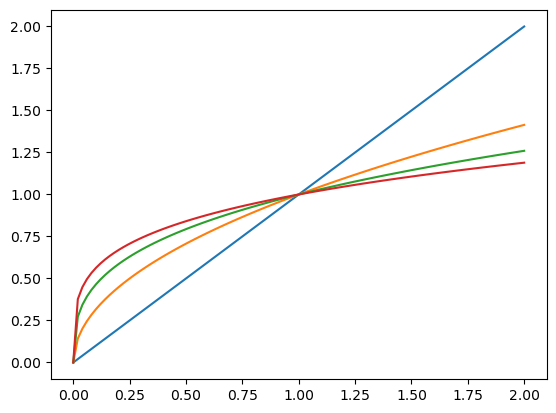

In [33]:
xs=np.linspace(0,2,100)
ys=np.sqrt(xs)
plt.plot(xs,xs)
plt.plot(xs,xs**(1/2))
plt.plot(xs,xs**(1/3))
plt.plot(xs,xs**(1/4))

In [1]:
import pyvista as pv
import numpy as np


points=np.array([
    [1,0,0],
    [0,0,1],
    [-1,0,0],
    [0,0,-1]
],dtype=np.float32)
labels=['1','2','3','4']
plotter=pv.Plotter()

actor=plotter.add_point_labels(points=points,labels=labels)

In [11]:
textMapperC = vtk.vtkTextMapper()
textMapperC.SetInput("This is\nmulti-line\ntext output\n(centered)")
tprop = textMapperC.GetTextProperty()
# tprop.ShallowCopy(multiLineTextProp)
tprop.SetJustificationToCentered()
tprop.SetVerticalJustificationToCentered()
# tprop.SetColor(colors.GetColor3d("DarkGreen"))

actor = vtk.vtkActor2D()
actor.SetMapper(textMapperC)
actor.GetPositionCoordinate().SetCoordinateSystemToNormalizedDisplay()
actor.GetPositionCoordinate().SetValue(0.5, 0.5)


D:\programs\miniconda3\envs\pywfn\lib\site-packages\pyvista\jupyter\notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


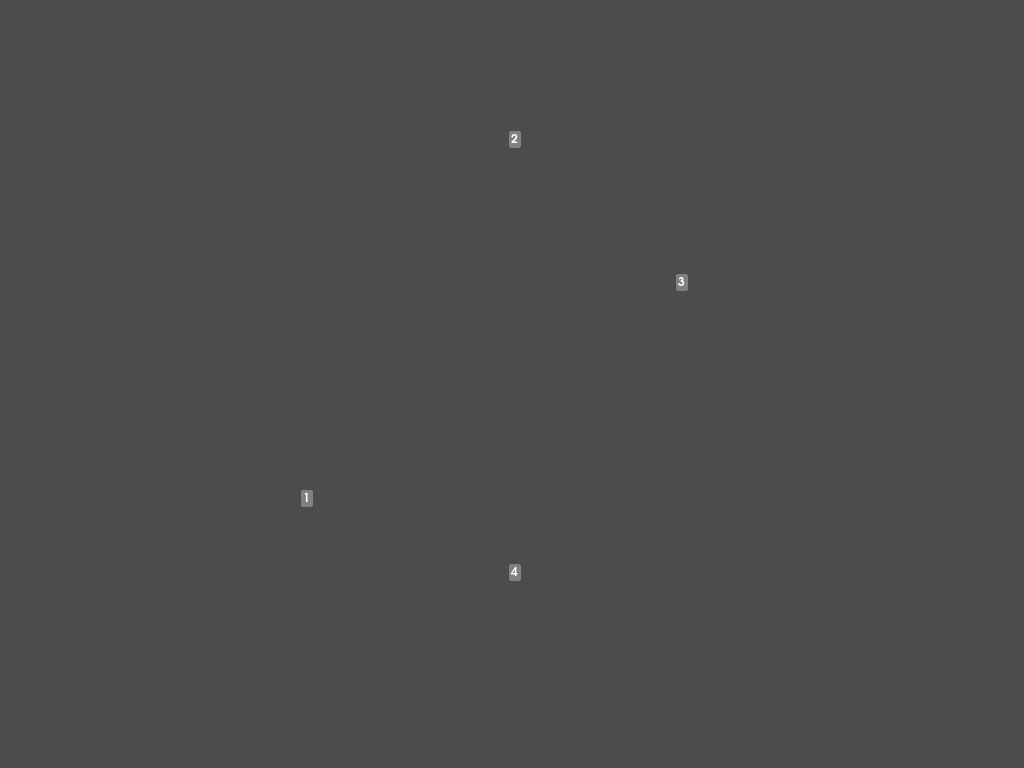

In [12]:
plotter.show()

In [6]:
import vtk
actor2=vtk.vtkActor2D()
print(actor2)

vtkActor2D (000002BDA788AEC0)
  Debug: Off
  Modified Time: 2277
  Reference Count: 1
  Registered Events: (none)
  Dragable: On
  Pickable: On
  AllocatedRenderTime: 10
  EstimatedRenderTime: 0
  NumberOfConsumers: 0
  RenderTimeMultiplier: 1
  Visibility: On
  PropertyKeys: none.
  useBounds: 1
  Layer Number: 0
  PositionCoordinate: 000002BDA789C5D0
    Debug: Off
    Modified Time: 2273
    Reference Count: 2
    Registered Events: (none)
    Coordinate System: Viewport
    Value: (0,0,0)
    ReferenceCoordinate: (none)
    Viewport: (none)
  Position2 Coordinate: 000002BDA789BDD0
    Debug: Off
    Modified Time: 2277
    Reference Count: 1
    Registered Events: (none)
    Coordinate System: Normalized Viewport
    Value: (0.5,0.5,0)
    ReferenceCoordinate: 000002BDA789C5D0
    Viewport: (none)
  Property: 0000000000000000
  Mapper: 0000000000000000




In [8]:
actor2.GetTextProperty()

AttributeError: 'vtkmodules.vtkRenderingCore.vtkActor2D' object has no attribute 'GetTextProperty'